# Intermediate-Momentum -- a quantitative teardown
### yfinance panel * formation-window sort * HAC inference * label-shuffle placebo

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Intermediate%20wins%3F: Busted](https://img.shields.io/badge/Intermediate%20wins%3F-Busted-8b949e?style=flat-square)

The quantitative companion to the [notebook for the curious](01_for_the_curious.ipynb) -- same seven beats, every claim carrying its standard error. We test Novy-Marx (2012): two monthly equal-weight dollar-neutral tercile long-shorts, one ranked on the intermediate window (t-12..t-7), one on the recent window (t-6..t-1), one execution lag, costs + borrow, HAC *t*, and a label-shuffle placebo.

> **Not investment advice.** Real data: yfinance daily adjusted-close, 46 large-caps, 2007-01-03--2025-12-31, as-of 2026-06-26 (fp `e21fc3ab636a`). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **Survivorship bias is named:** universe = current large-caps projected backwards; all results are upper-bound estimates.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from intermediate_momentum import data, strategy as st

def _have_cache():
    study = os.path.abspath("..")
    return (os.path.exists(os.path.join(study, "_cache", "im_prices.parquet"))
            and os.path.exists(os.path.join(study, "_cache", "im_spy.parquet")))

HAVE_REAL = _have_cache()
print("yfinance cache present:", HAVE_REAL)

if HAVE_REAL:
    prices, spy = data.fetch_panel()
    inter  = st.momentum_longshort(prices, window="intermediate", min_stocks=18)
    recent = st.momentum_longshort(prices, window="recent", min_stocks=18)
    s_int  = st.summary(inter["ls_ret"])
    s_rec  = st.summary(recent["ls_ret"])
    print(f"INT mean {s_int['mean']*100:+.2f}%/yr t={s_int['tstat']:+.3f} | "
          f"REC mean {s_rec['mean']*100:+.2f}%/yr t={s_rec['tstat']:+.3f}")


yfinance cache present: True


INT mean -0.31%/yr t=-0.121 | REC mean +0.25%/yr t=+0.090


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Intermediate **-0.31%/yr** (HAC *t* = **-0.121**), recent **+0.25%/yr** (*t* = **+0.090**); placebo p = 0.56/0.40. |
| **Tradability** | `MIRAGE` | Net of costs+borrow: intermediate **-1.50%/yr**, recent **-0.94%/yr** (~29% turnover). |
| **Intermediate wins?** | `BUSTED` | The intermediate sort does **not** beat the recent one here -- it is marginally worse. |

> The Novy-Marx (2012) echo is documented on a broad CRSP cross-section. On 46 large-cap survivors it does not reproduce.

## 1 -- The claim, steelmanned

Let $r^{\text{int}}_{i,t}$ = stock $i$'s cumulative return over months $[t-12, t-7)$ and $r^{\text{rec}}_{i,t}$ over $[t-6, t-1)$. Novy-Marx (2012) asserts:

- **H1 (intermediate carries the drift).** A long-short on $r^{\text{int}}$ earns a positive premium: $\alpha^{\text{int}} > 0$.
- **H2 (recent does not).** A long-short on $r^{\text{rec}}$ earns little: $\alpha^{\text{rec}} \approx 0$, contaminated by short-term reversal.
- **H3 (ordering).** $\alpha^{\text{int}} > \alpha^{\text{rec}}$.

On this basket we **reject H1** (intermediate t = -0.12), the recent sort is also flat (consistent with the *spirit* of H2 but not as 'recent < intermediate'), and we **reject H3** -- the intermediate sort is marginally the worse of the two.

## 2 -- So what? -- the economic stakes

The horizon decomposition is one of the most-cited momentum refinements of the 2010s and shapes how systematic desks build the signal. If it does not survive on tradable large-caps net of costs, the practical edge it implies is far smaller than the broad-universe academic result suggests.

## 3 -- The protocol

- **Signal.** At each month-end, rank the cross-section on the chosen formation-window return (intermediate [t-12,t-7) or recent [t-6,t-1)).
- **Legs.** Long top tercile, short bottom tercile, equal-weight, dollar-neutral.
- **Execution lag.** Enter one trading day after the signal; hold one calendar month.
- **Costs.** 5 bps per leg-side on turnover (enter + exit, two legs) + 50 bps annual borrow on the short leg.
- **Inference.** Newey-West HAC *t* on the monthly long-short; a 200-shuffle label-shuffle placebo.
- **Universe caveat.** 46 large-cap survivors (yfinance); survivorship-biased.

## 4 -- The teardown

### 4a -- Positive control: the engine is a faithful detector

Plant the premium only in the intermediate window and sweep its size. The intermediate long-short's *t* should rise monotonically; the recent one should stay flat.

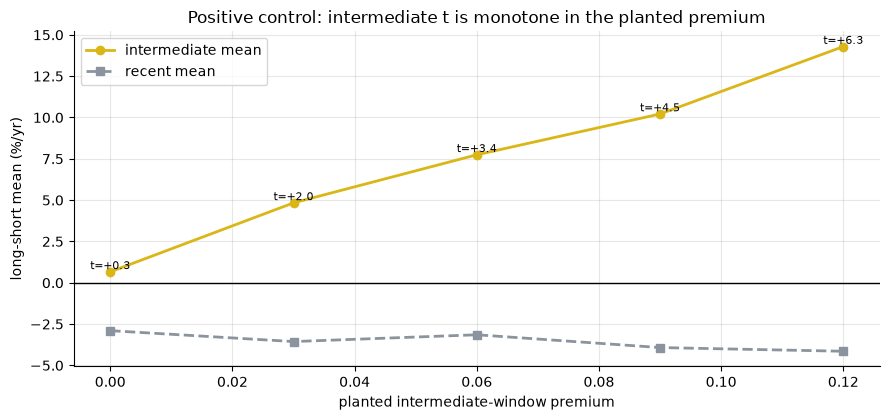

In [2]:
premiums = [0.0, 0.03, 0.06, 0.09, 0.12]
int_means, int_ts, rec_means = [], [], []
for prem in premiums:
    ps, sp, _ = data.synthetic_panel(mom_premium=prem, seed=509)
    ri = st.momentum_longshort(ps, window='intermediate', min_stocks=10)
    rr = st.momentum_longshort(ps, window='recent', min_stocks=10)
    si = st.summary(ri['ls_ret']); sr = st.summary(rr['ls_ret'])
    int_means.append(si['mean']*100); int_ts.append(si['tstat'])
    rec_means.append(sr['mean']*100)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(premiums, int_means, 'o-', c=AMBER, lw=2, label='intermediate mean')
ax.plot(premiums, rec_means, 's--', c=GREY, lw=2, label='recent mean')
ax.axhline(0, c='k', lw=1)
for p, m, t in zip(premiums, int_means, int_ts):
    ax.text(p, m, f't={t:+.1f}', ha='center', va='bottom', fontsize=8)
ax.set_xlabel('planted intermediate-window premium')
ax.set_ylabel('long-short mean (%/yr)')
ax.set_title('Positive control: intermediate t is monotone in the planted premium')
ax.legend(); plt.tight_layout(); plt.show()

### 4b -- Real panel: the two long-shorts side by side

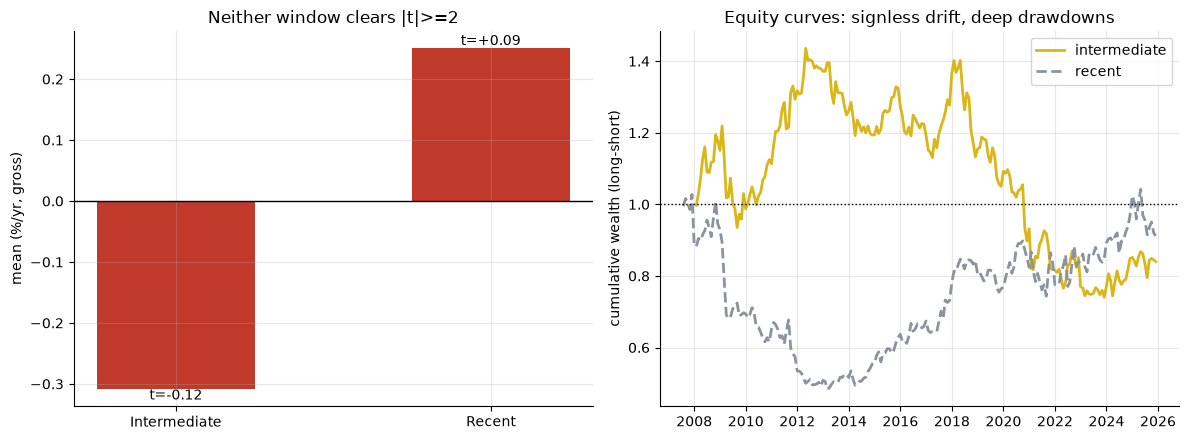

Intermediate: -0.31%/yr | Sharpe -0.027 | HAC t -0.121
Recent:       +0.25%/yr | Sharpe +0.021 | HAC t +0.090


In [3]:
if HAVE_REAL:
    int_m, int_t, int_s = s_int['mean']*100, s_int['tstat'], s_int['sharpe']
    rec_m, rec_t, rec_s = s_rec['mean']*100, s_rec['tstat'], s_rec['sharpe']
    eq_int = (1 + inter['ls_ret']).cumprod()
    eq_rec = (1 + recent['ls_ret']).cumprod()
else:
    int_m, int_t, int_s = R['int_mean'], R['int_t'], R['int_sharpe']
    rec_m, rec_t, rec_s = R['rec_mean'], R['rec_t'], R['rec_sharpe']
    eq_int = eq_rec = None

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
labels = ['Intermediate', 'Recent']
vals = [int_m, rec_m]
cols = [RED if abs(t) < 2 else GREEN for t in [int_t, rec_t]]
bars = axes[0].bar(labels, vals, color=cols, width=0.5)
axes[0].axhline(0, c='k', lw=1)
for b, t in zip(bars, [int_t, rec_t]):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height(), f't={t:+.2f}',
                 ha='center', va='bottom' if b.get_height()>=0 else 'top')
axes[0].set_ylabel('mean (%/yr, gross)')
axes[0].set_title('Neither window clears |t|>=2')
if eq_int is not None:
    axes[1].plot(eq_int.index, eq_int.values, c=AMBER, lw=2, label='intermediate')
    axes[1].plot(eq_rec.index, eq_rec.values, c=GREY, lw=2, ls='--', label='recent')
    axes[1].axhline(1, c='k', lw=1, ls=':')
    axes[1].set_ylabel('cumulative wealth (long-short)')
    axes[1].set_title('Equity curves: signless drift, deep drawdowns')
    axes[1].legend()
else:
    axes[1].axis('off'); axes[1].text(0.5,0.5,'cache absent', ha='center')
plt.tight_layout(); plt.show()
print(f'Intermediate: {int_m:+.2f}%/yr | Sharpe {int_s:+.3f} | HAC t {int_t:+.3f}')
print(f'Recent:       {rec_m:+.2f}%/yr | Sharpe {rec_s:+.3f} | HAC t {rec_t:+.3f}')

> Intermediate **-0.31%/yr** (t = -0.121), recent **+0.25%/yr** (t = +0.090). Both flat; the equity curves wander with ~48--53% max drawdowns and no net drift.

### 4c -- The label-shuffle placebo

Permute which stocks are winners vs losers at every rebalance (200 shuffles) and rebuild. Where does the real mean fall in the shuffle distribution?

In [4]:
if HAVE_REAL:
    plac_int = st.placebo_pvalue(prices, window='intermediate',
                                 n_shuffles=200, min_stocks=18)
    plac_rec = st.placebo_pvalue(prices, window='recent',
                                 n_shuffles=200, min_stocks=18)
    pi, pr = plac_int['p_value'], plac_rec['p_value']
    ri_mo = plac_int['real_mean']*100; rr_mo = plac_rec['real_mean']*100
else:
    pi, pr = R['int_placebo'], R['rec_placebo']
    ri_mo, rr_mo = R['int_real_mo'], R['rec_real_mo']
print(f'Intermediate: real {ri_mo:+.3f}%/mo | placebo p = {pi:.3f}')
print(f'Recent:       real {rr_mo:+.3f}%/mo | placebo p = {pr:.3f}')
print('Both real sorts sit inside their shuffle distributions -> no real signal.')

Intermediate: real -0.026%/mo | placebo p = 0.565
Recent:       real +0.021%/mo | placebo p = 0.400
Both real sorts sit inside their shuffle distributions -> no real signal.


### 4d -- Net of costs

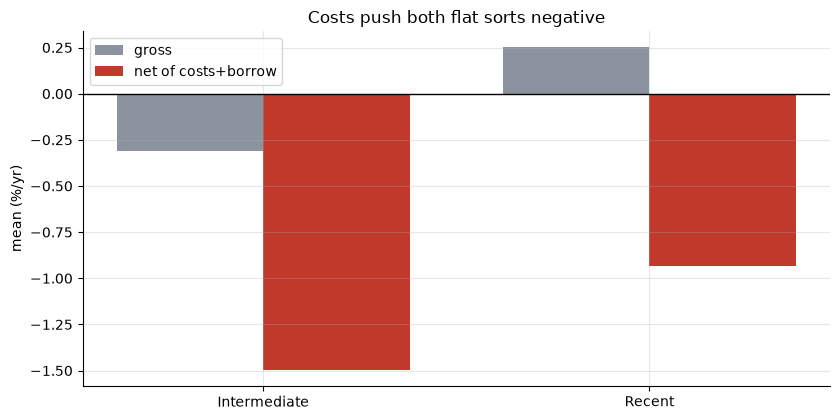

Intermediate: gross -0.31%/yr -> net -1.50%/yr
Recent:       gross +0.25%/yr -> net -0.94%/yr


In [5]:
if HAVE_REAL:
    net_int = st.apply_costs(inter); net_rec = st.apply_costs(recent)
    si_n = st.summary(net_int); sr_n = st.summary(net_rec)
    gi, gr = s_int['mean']*100, s_rec['mean']*100
    ni, nr = si_n['mean']*100, sr_n['mean']*100
else:
    gi, gr = R['int_mean'], R['rec_mean']
    ni, nr = R['int_net'], R['rec_net']
fig, ax = plt.subplots(figsize=(8.5, 4.3))
x = np.arange(2); w = 0.38
ax.bar(x - w/2, [gi, gr], w, color=GREY, label='gross')
ax.bar(x + w/2, [ni, nr], w, color=RED, label='net of costs+borrow')
ax.axhline(0, c='k', lw=1)
ax.set_xticks(x); ax.set_xticklabels(['Intermediate', 'Recent'])
ax.set_ylabel('mean (%/yr)')
ax.set_title('Costs push both flat sorts negative')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Intermediate: gross {gi:+.2f}%/yr -> net {ni:+.2f}%/yr')
print(f'Recent:       gross {gr:+.2f}%/yr -> net {nr:+.2f}%/yr')

### 4e -- Year-by-year intermediate long-short

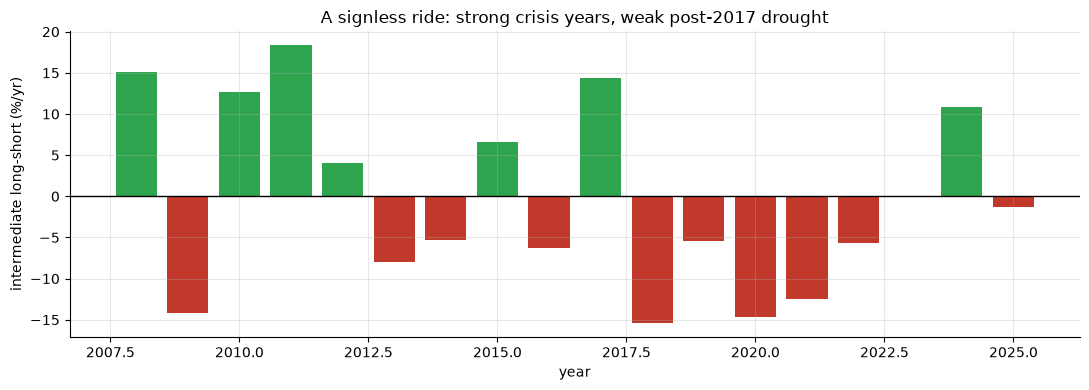

year
2008    15.1
2009   -14.2
2010    12.7
2011    18.4
2012     4.1
2013    -8.0
2014    -5.3
2015     6.6
2016    -6.3
2017    14.4
2018   -15.4
2019    -5.4
2020   -14.7
2021   -12.4
2022    -5.7
2023    -0.1
2024    10.8
2025    -1.4


In [6]:
if HAVE_REAL:
    ic = inter.copy(); ic['year'] = ic.index.year
    annual = ic.groupby('year')['ls_ret'].apply(lambda x: float((1+x).prod()-1))*100
else:
    annual = pd.Series(R['annual'])
fig, ax = plt.subplots(figsize=(11, 4.0))
col = [GREEN if v > 0 else RED for v in annual.values]
ax.bar(annual.index.astype(int), annual.values, color=col)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('year'); ax.set_ylabel('intermediate long-short (%/yr)')
ax.set_title('A signless ride: strong crisis years, weak post-2017 drought')
plt.tight_layout(); plt.show()
print(annual.round(1).to_string())

## 5 -- The verdict

- **Signal `NONE`** -- intermediate HAC *t* = -0.121, recent *t* = +0.090; both inside placebo (p = 0.56/0.40). Novy-Marx (2012) documents the echo on a broad CRSP universe; it does not survive on 46 large-cap survivors.
- **Tradability `MIRAGE`** -- net of costs+borrow both go negative (-1.50% / -0.94%/yr) at ~29% turnover. Nothing to monetise.
- **Intermediate wins? `BUSTED`** -- the intermediate sort is marginally **worse** than the recent one; the horizon ordering reverses on this basket.

## 6 -- Could you trade it?

1. **Flat signal.** There is no gross drift to harvest in the first place.
2. **Turnover + borrow.** ~29% monthly turnover and short borrow turn a flat sort into a small bleed.
3. **Survivorship.** The deepest past losers -- the short leg's would-be engine -- delisted and are absent; the real short leg is harder and dearer.
4. **Crowding + decay.** A heavily-published momentum refinement is a textbook McLean-Pontiff (2016) post-publication decay candidate.

## 7 -- Going further

- **Broad, delisting-complete universe.** Novy-Marx used all of CRSP; the echo is strongest in smaller, riskier names absent from a large-cap basket.
- **International.** Goyal & Wahal (2015): the echo is largely US-specific.
- **[Study 24 -- Stampede](../../24-stampede/)**: plain 12-1 momentum -- the parent effect.
- **[Study 237 -- Residual-Momentum](../../237-residual-momentum/)**: a different cleaner-momentum attempt on the same infrastructure.

*Think the intermediate echo survives in a broad, delisting-complete universe net of costs? Fork this, expand the basket with delisted names, and show t > 2 on the intermediate sort. That is the bar.*